<a href="https://colab.research.google.com/github/havvy001/ira-sync-server/blob/main/green_city_spaces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install geopandas osmnx networkx matplotlib contextily


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.1 MB/s eta 0:00:00


In [ ]:
import osmnx as ox
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import folium
from shapely.geometry import point

In [ ]:
#set a central point in Berlin(Brandenburg Gate)
latitude = 52.5163
longitude = 13.3777
#create a bounding graph from a 1km radius
G=ox.graph_from_point((latitude,longitude),dist=1000,network_type='walk')

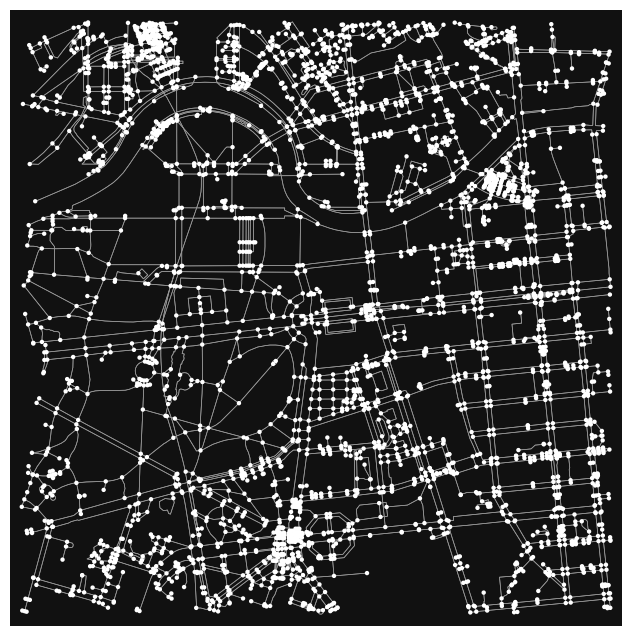

In [ ]:
#plot the street network
fig ,ax=ox.plot_graph(G, node_size=10,edge_linewidth=0.5)

<Axes: >

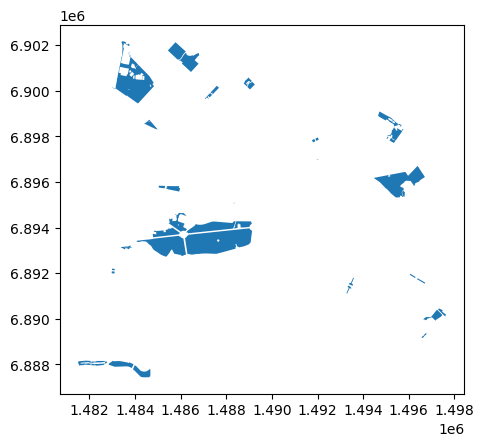

In [ ]:
tags={'leisure':['park','garden','recreation_ground','nature_reserve']}
#get green areas(polygon geometries)
#use ox.features_from_point instead of ox.features_from_place
#geometries_from_place has been replaced by features_from_point or geometries_from_polygon
green_spaces = ox.features_from_point((latitude,longitude),tags=tags, dist=5000)

#Filter polygons only
green_spaces= green_spaces[green_spaces.geometry.type.isin(['polygon','MultiPolygon'])]
green_spaces=green_spaces.to_crs(epsg=3857)
green_spaces.plot()


<Axes: >

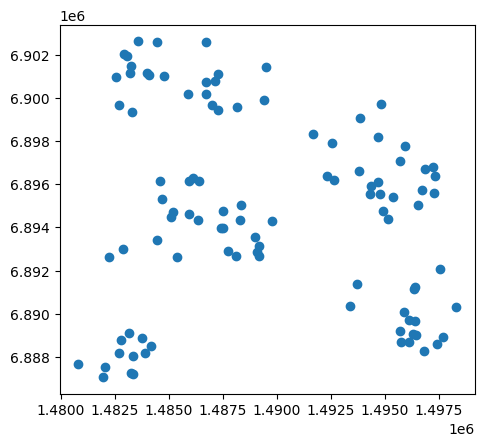

In [ ]:
import random
from shapely.geometry import Point,Polygon
from shapely.ops import unary_union

#create convex hull or bounding polygon
area_polygon= unary_union(green_spaces.buffer(1000).geometry)
#Generate random residential points from polygon
res_points=[]
while len(res_points)< 100:
  x=random.uniform(area_polygon.bounds[0],area_polygon.bounds[2])
  y=random.uniform(area_polygon.bounds[1],area_polygon.bounds[3])
  point = Point (x,y)
  if area_polygon.contains(point):
     res_points.append(point)
res_gdf= gpd.GeoDataFrame(geometry=res_points,crs="EPSG:3857")
# The line below was causing an error as 'plot' is not defined.
# If you intended to plot the GeoDataFrame, use res_gdf.plot()
#res_gdf=plot()
res_gdf.plot()

In [ ]:
# Convert res_gdf to WGS84 for consistency with the network graph
res_gdf=res_gdf.to_crs(epsg=4326)

# Ensure green_spaces is in a projected CRS (EPSG:3857) for accurate centroid calculation
green_spaces_proj = green_spaces.to_crs(epsg=3857)

# Calculate centroids while it's in the projected CRS (3857) to avoid the warning.
park_centroids_proj = green_spaces_proj.geometry.centroid

# Convert the calculated centroids from the projected CRS (3857) to WGS84 (4326)
# as ox.distance.nearest_nodes expects (lon, lat) which is WGS84.
park_centroids = park_centroids_proj.to_crs(epsg=4326)

# get nearest nodes on the walking network
nearest_nodes=[ox.distance.nearest_nodes(G,point.x,point.y)for point in res_gdf.geometry]
park_nodes= [ox.distance.nearest_nodes(G,point.x,point.y)for point in park_centroids]

In [ ]:
#build a dataframe of shortest distance
distances=[]
for res_node in nearest_nodes:
  min_distance=min(nx.shortest_path_length(G,res_node,park_node,weight='length') for park_node in park_nodes)
  distances.append(min_distance)

#Add to GeoDataFrame after the loop has completed
res_gdf['green_space_distance_m']=distances
res_gdf['green_space_distance_km']=res_gdf['green_space_distance_m']/1000

In [ ]:
#create a folium map centered at the area
m = folium.Map(location=[latitude, longitude], zoom_start=12)

#add green spaces
for _, row in green_spaces.iterrows():
  folium.GeoJson(row.geometry,style_function=lambda x:{'color':'green'}).add_to(m)

#add residential points
for _,row in res_gdf.iterrows():
  folium.CircleMarker(
      location=[row.geometry.y,row.geometry.x],
      radius=5,
      popup=f"Distance : {row.green_space_distance_km:.2f}km",
      color='blue',
      fill_opacity=0.7
  ).add_to(m)


In [ ]:
res_gdf.to_file("residential_green_access.geojson",driver="GeoJSON")

To save a GeoDataFrame, like `res_gdf`, to a file, you use the `.to_file()` method. Here's how it works:

```python
res_gdf.to_file("output_filename.geojson", driver="GeoJSON")
```

-   `"output_filename.geojson"`: This is the path and name of the file you want to create. The file extension often helps `geopandas` determine the correct `driver`.
-   `driver="GeoJSON"`: This specifies the file format driver to use. Common drivers include `"GeoJSON"`, `"ESRI Shapefile"`, `"GPKG"` (for GeoPackage), etc. You might not always need to specify this if the file extension is unambiguous.

In [ ]:
print('res_gdf' in globals())

True


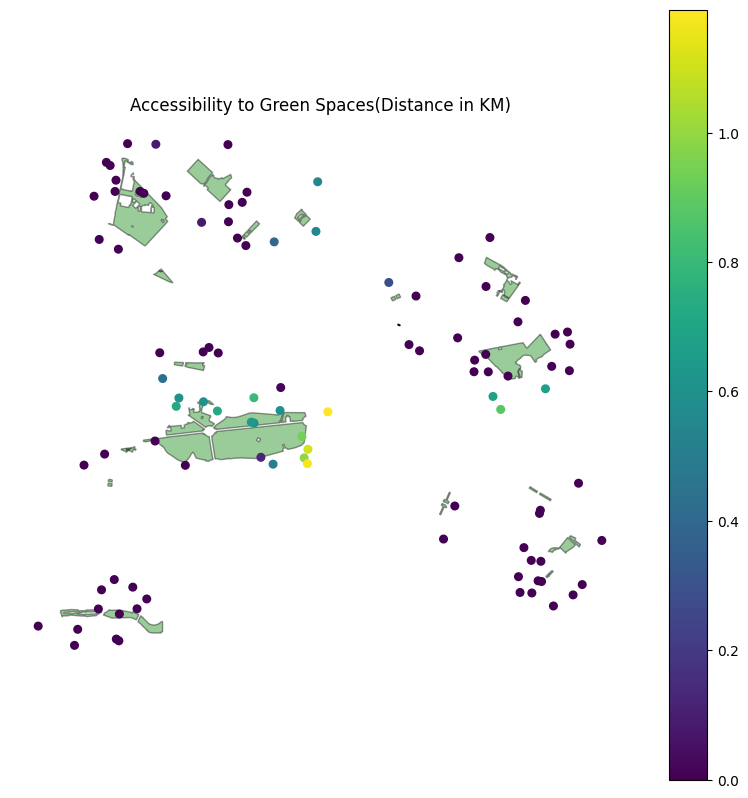

In [ ]:
import matplotlib.pyplot as plt

#reproject to metric for consistent map scaling
res_gdf_plot=res_gdf.to_crs(epsg=3857)

#plot
fig,ax=plt.subplots(figsize=(10,10))
green_spaces.to_crs(epsg=3857).plot(ax=ax,color='green',alpha=0.4,edgecolor='black')
res_gdf_plot.plot(ax=ax,column='green_space_distance_km',cmap='viridis',legend=True,markersize=30)

plt.title("Accessibility to Green Spaces(Distance in KM)")
plt.axis("Off")
plt.show()

In [29]:
import folium
from branca.colormap import linear

# --- Ensure your data exists (res_gdf, green_spaces, lat, lon) ---

# Color scale
color_scale = linear.viridis.scale(
    res_gdf['green_space_distance_km'].min(),
    res_gdf['green_space_distance_km'].max()
)

# Basemap with working tile provider
m = folium.Map(
    location=[latitude, longitude],
    zoom_start=12,
    tiles='CartoDB positrum',
    attr='&copy; <a href="https://carto.com/attributions">Carto</a>'   # <--- KEY CHANGE
)

# Add green spaces
for _, row in green_spaces.iterrows():
    folium.GeoJson(
        row.geometry,
        style_function=lambda x: {'color': 'green', 'fillOpacity': 0.3}
    ).add_to(m)

# Add residential points
for _, row in res_gdf.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6,
        color=color_scale(row['green_space_distance_km']),
        fill=True,
        fill_opacity=0.9,
        popup=f"Distance: {row['green_space_distance_km']:.2f} km",
    ).add_to(m)

color_scale.caption = "Distance to Nearest Green Space (km)"
color_scale.add_to(m)

# Display in Colab
display(m)

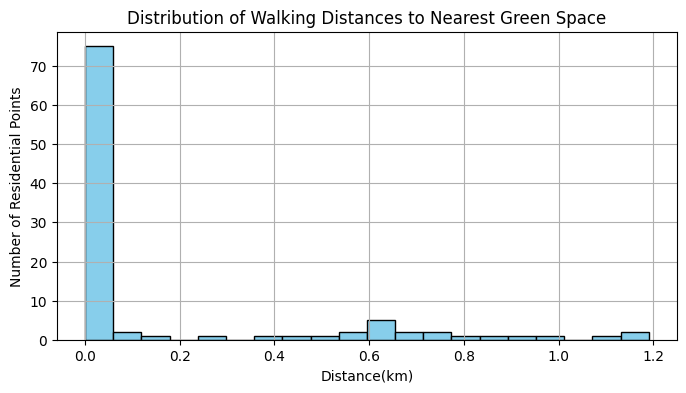

In [24]:
res_gdf['green_space_distance_km'].plot.hist(bins=20,color='skyblue',edgecolor='black',figsize=(8,4))
plt.title("Distribution of Walking Distances to Nearest Green Space")
plt.xlabel("Distance(km)")
plt.ylabel("Number of Residential Points")
plt.grid(True)
plt.show()

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Cumulative Distribution of Access to Green Spaces')

Text(0.5, 0, 'Distance to Nearest Green Space (km)')

Text(0, 0.5, 'Proportion of Residential Points')

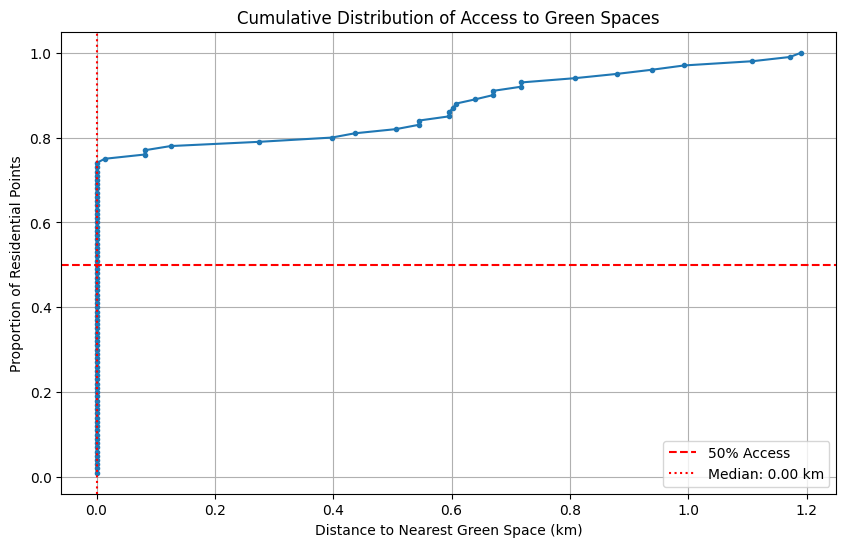

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Sort distances to create a cumulative distribution
sorted_distances = np.sort(res_gdf['green_space_distance_km'])
cumulative_proportion = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances)

plt.figure(figsize=(10, 6))
plt.plot(sorted_distances, cumulative_proportion, marker='.', linestyle='-')
plt.title('Cumulative Distribution of Access to Green Spaces')
plt.xlabel('Distance to Nearest Green Space (km)')
plt.ylabel('Proportion of Residential Points')
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--', label='50% Access')
plt.axvline(x=sorted_distances[int(len(sorted_distances) * 0.5)], color='r', linestyle=':', label=f'Median: {sorted_distances[int(len(sorted_distances) * 0.5)]:.2f} km')
plt.legend()
plt.show()

Distribution of Accessibility Levels (Percentages):
accessibility_level
Over 1km        3.0
Within 1km     16.0
Within 300m    79.0
Within 500m     2.0
Name: count, dtype: float64


<Figure size 800x500 with 0 Axes>

<Axes: xlabel='accessibility_level'>

Text(0.5, 1.0, 'Distribution of Accessibility Levels to Green Spaces (Percentages)')

Text(0.5, 0, 'Accessibility Level')

Text(0, 0.5, 'Percentage of Residential Points')

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Over 1km'),
  Text(1, 0, 'Within 1km'),
  Text(2, 0, 'Within 300m'),
  Text(3, 0, 'Within 500m')])

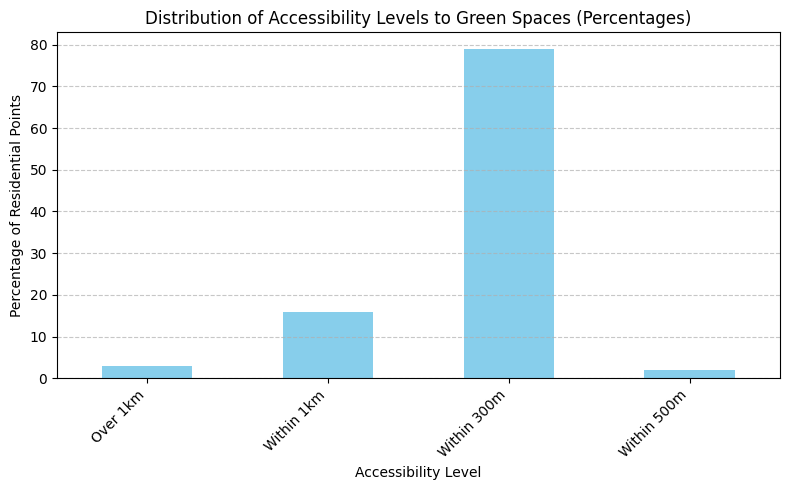

In [33]:
# Define accessibility levels based on distance to nearest green space
def categorize_accessibility(distance_km):
    if distance_km <= 0.3:
        return 'Within 300m'
    elif distance_km <= 0.5:
        return 'Within 500m'
    elif distance_km <= 1.0:
        return 'Within 1km'
    else:
        return 'Over 1km'

# Apply the categorization to the residential points GeoDataFrame
res_gdf['accessibility_level'] = res_gdf['green_space_distance_km'].apply(categorize_accessibility)

# Calculate percentages
accessibility_counts = res_gdf['accessibility_level'].value_counts()
total_points = len(res_gdf)
accessibility_percentages = (accessibility_counts / total_points * 100).sort_index()

# Display the percentages of points in each accessibility level
print("Distribution of Accessibility Levels (Percentages):")
print(accessibility_percentages)

# Visualize this distribution with a bar chart
plt.figure(figsize=(8, 5))
accessibility_percentages.plot(kind='bar', color='skyblue')
plt.title('Distribution of Accessibility Levels to Green Spaces (Percentages)')
plt.xlabel('Accessibility Level')
plt.ylabel('Percentage of Residential Points')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Figure size 700x700 with 0 Axes>

([<matplotlib.patches.Wedge at 0x7bfebb51c9e0>,
 [Text(-0.6741975677453381, -0.8691706619797234, '<300m'),
  Text(1.046162227084113, 0.33991851173834126, '301-500m'),
  Text(0.7011667451789526, 0.8475642721676946, '501m-1km'),
  Text(0.10351986117908972, 1.0951180933312452, '>1km')],
 [Text(-0.36774412786109345, -0.47409308835257635, '79.0%'),
  Text(0.5706339420458798, 0.18541009731182248, '2.0%'),
  Text(0.38245458827942863, 0.46230778481874246, '16.0%'),
  Text(0.056465378824958015, 0.5973371418170428, '3.0%')])

Text(0.5, 1.0, 'Green Space Accessibility (Walking Distance)')

(np.float64(-1.0999999972102388),
 np.float64(1.0999999732928751),
 np.float64(-1.0999999901206061),
 np.float64(1.0999999995295526))

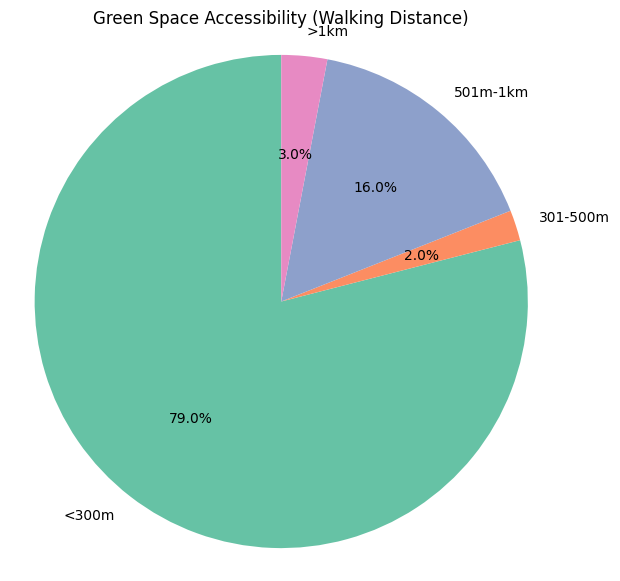

In [35]:
import matplotlib.pyplot as plt

labels = ['<300m', '301-500m', '501m-1km', '>1km']
sizes = [
    accessibility_percentages.loc['Within 300m'],
    accessibility_percentages.loc['Within 500m'],
    accessibility_percentages.loc['Within 1km'],
    accessibility_percentages.loc['Over 1km']
]

colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Green Space Accessibility (Walking Distance)')
plt.axis('equal')
plt.show()

In [37]:
within_300m = accessibility_percentages.loc['Within 300m']
within_500m = accessibility_percentages.loc['Within 500m']
within_1km = accessibility_percentages.loc['Within 1km']
over_1km = accessibility_percentages.loc['Over 1km']

# Generate a written summary
summary = f'''
✔ CONCLUSION:
- On average, people in this 1km area are {res_gdf['green_space_distance_km'].mean():.2f} km away from the nearest green space.
- {within_300m:.1f}% of residents live within 300 meters — which is considered excellent accessibility.
- {within_500m:.1f}% are within 500 meters, and {within_1km:.1f}% within 1 km.
- However, {over_1km:.1f}% of residents are over 1 km away from any green space — indicating underdeveloped urban areas.

This data can help city planners identify green space gaps and prioritize future investments in urban planning.
'''
print(summary)


✔ CONCLUSION:
- On average, people in this 1km area are 0.16 km away from the nearest green space.
- 79.0% of residents live within 300 meters — which is considered excellent accessibility.
- 2.0% are within 500 meters, and 16.0% within 1 km.
- However, 3.0% of residents are over 1 km away from any green space — indicating underdeveloped urban areas.

This data can help city planners identify green space gaps and prioritize future investments in urban planning.

